# Note that this project is coded for R

<center><img src="prog_lang.jpg" width=500></center>

## Background
How can you determine which programming languages and technologies are most widely used? Which languages are gaining or losing popularity, helping you decide where to focus your efforts?

One excellent data source is Stack Overflow, a programming question-and-answer site with more than 16 million questions on programming topics. Each Stack Overflow question is tagged with a label identifying its topic or technology. By counting the number of questions related to each technology, you can estimate the popularity of different programming languages.


## The Data
In this project, you will use data from the Stack Exchange Data Explorer to examine the relative popularity of R compared to other programming languages.

You'll work with a dataset containing one observation per tag per year, including the number of questions for that tag and the total number of questions that year.

`stack_overflow_data.csv`
|Column|Description|
|------|-----------|
|`year`|The year the question was asked (2008-2020)|
|`tag`|A word or phrase that describes the topic of the question, such as the programming language|
|`num_questions`|The number of questions with a certain tag in that year|
|`year_total`|The total number of questions asked in that year|

# Objectives
Discover the trends in the popularity of programming languages by answering the following questions:
1) What percentage of questions are tagged with `r` per year? Save the result in a data frame, `r_over_time`, containing five columns: `year`, `tag`, `num_questions`, `year_total`, and `percentage` (proportion of `r` questions).

2) What was the percentage of `R` questions for 2020? Save the result in a data frame, `r_2020`, containing five columns: `year`, `tag`, `num_questions`, `year_total`, & `percentage`.

3) Identify the five programming language tags with the highest total number of questions asked between 2015 and 2020 (inclusive). Save the tag names as a character vector, `highest_tags`.

In [37]:
# Load necessary packages
library(readr)
library(dplyr)
library(ggplot2)
library(tidyverse)
library(stringr)

In [38]:
#load the dataset
data <- read_csv("stack_overflow_data.csv")
    #420,066 rows
#view the dataset
head(data)

Rows: 420066 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): tag
dbl (3): year, num_questions, year_total

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


year,tag,num_questions,year_total
<dbl>,<chr>,<dbl>,<dbl>
2008,treeview,69,168541
2008,scheduled-tasks,30,168541
2008,specifications,21,168541
2008,rendering,35,168541
2008,http-post,6,168541
2008,static-assert,1,168541


In [39]:
#data inspection
data %>% filter(tag == 'r')

year,tag,num_questions,year_total
<dbl>,<chr>,<dbl>,<dbl>
2008,r,8,168541
2009,r,523,981124
2010,r,2264,1970729
2011,r,5835,3473395
2012,r,12183,4787010
2013,r,22256,6037170
2014,r,30923,6431458
2015,r,40704,6612772
2016,r,44365,6593600


# Q1
What percentage of questions are tagged with `r` per year? Save the result in a data frame, `r_over_time`, containing five columns: `year`, `tag`, `num_questions`, `year_total`, and `percentage` (proportion of `r` questions).

In [40]:
#Q1 -- What percentage of questions are tagged with r per year?
r_over_time <- data %>%
  filter(tag == "r") %>%
  mutate(percentage = 100*(num_questions/year_total))

r_over_time
  #13 observations, 5 variables

year,tag,num_questions,year_total,percentage
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2008,r,8,168541,0.00474662
2009,r,523,981124,0.05330621
2010,r,2264,1970729,0.11488135
2011,r,5835,3473395,0.16799126
2012,r,12183,4787010,0.25450124
2013,r,22256,6037170,0.36864955
2014,r,30923,6431458,0.48080855
2015,r,40704,6612772,0.61553612
2016,r,44365,6593600,0.67284943


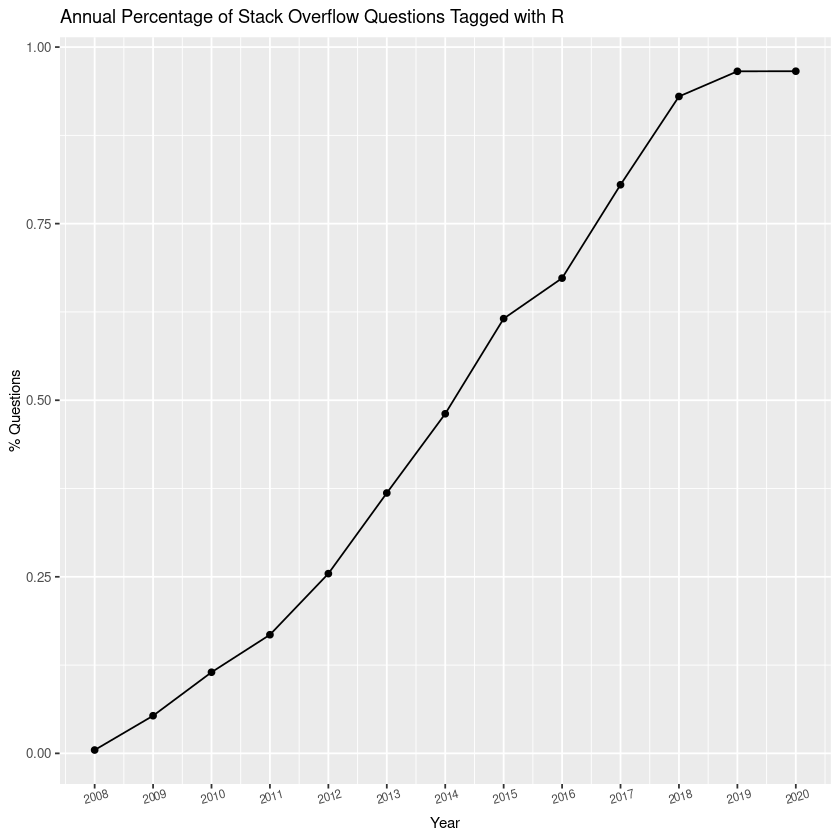

In [41]:
#make a plot
q1_plot_I <- ggplot(data=r_over_time, aes(x=year, y=percentage)) +
  geom_line() + geom_point() +
  labs(title="Annual Percentage of Stack Overflow Questions Tagged with R", 
       x="Year",y="% Questions") +
  scale_x_continuous(breaks=c(2007:2020)) +
  theme(axis.text.x = element_text(size=7, angle=15),
        axis.text.y = element_text(size=8),
        plot.title = element_text(size=11),
        axis.title.x = element_text(size=9), axis.title.y = element_text(size=9))
q1_plot_I


The plot above illustrates the percentage of questions on Stack Overflow which were tagged with 'R' per year from 2008-2020. Across this timespan, over 420,000 questions were prompted on the site. In 2008, only eight questions (about 0.0047% of all questions) were asked pertaining to the programming language, R. In 2020, however, this number had risen to 52,662, or about 0.97% of all questions.

There is a clear increasing trend regarding the popularity of R on Stack Overflow over this time period; however, it seems to have stabilized in the most recent years (2018-2020).

# Q2
What was the percentage of `R` questions for 2020? Save the result in a data frame, `r_2020`, containing five columns: `year`, `tag`, `num_questions`, `year_total`, & `percentage`.

In [42]:
#Q2 -- What was the percentage of R questions for 2020?

r_2020 <- r_over_time %>% filter(year == 2020)
r_2020
    # ~ 0.966%

year,tag,num_questions,year_total,percentage
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2020,r,52662,5452545,0.9658242


# Q3
Identify the five programming language tags with the highest total number of questions asked between 2015 and 2020 (inclusive). Save the tag names as a character vector, `highest_tags`.

In [43]:
#Q3 -- Identify the five programming language tags with the highest total number of questions asked between 
    #2015 and 2020 (inclusive)

Q3_data <- data %>%
  filter(year > 2014) %>%
  group_by(tag) %>%
  summarize(total_Qs = sum(num_questions)) %>%
  arrange(desc(total_Qs)) %>%
  #only select 5 most popular tags
  head(n=5) %>%
  #reorder based on 'total_Qs' (for plot later)
  mutate(tag = reorder(tag, total_Qs))

highest_tags <- as.vector(Q3_data$tag)
highest_tags
  #OUTPUT: ["javascript", "python", "java", "android", "c#"]

[1] "javascript" "python"     "java"       "android"    "c#"

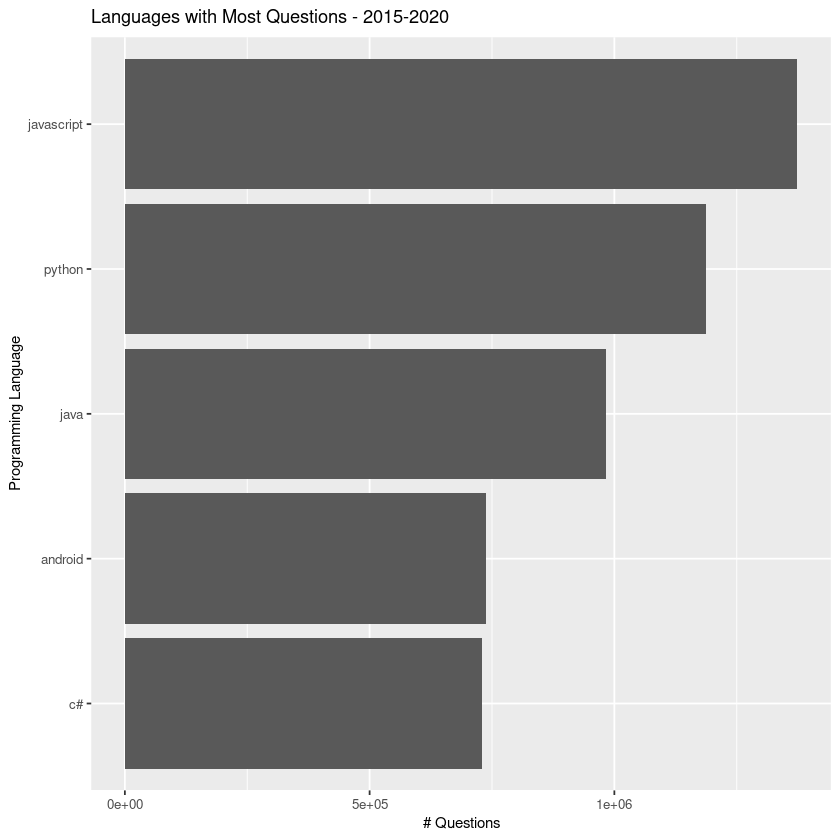

In [44]:
#make a plot
q3_plot_I <- ggplot(data=Q3_data, aes(y=tag, x=total_Qs)) + 
  geom_col() +
  labs(title="Languages with Most Questions - 2015-2020", x="# Questions", y='Programming Language') +
  theme(plot.title=element_text(size=11),
        axis.title.x = element_text(size=9), axis.title.y = element_text(size=9),
        axis.text.x = element_text(size=8), axis.text.y = element_text(size=8))
q3_plot_I

The plot above displays the five programming languages that received the most questions on Stack Overflow from 2015-2020. From most to least, these languages are: javascript, python, java, android, & c#. Javascript had about 1,370,000 questions whereas C# only had about 730,000 questions.